# Градиентный бустинг

Исследуем влияние learning rate и числа деревьев, выберем конфигурацию по ROC-AUC и проанализируем качество и важность признаков.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

In [2]:
data = pd.read_csv("data.csv")
features = data.drop(columns="target")
target = data["target"]
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.25, random_state=42, stratify=target
)
print("Размер:", data.shape)
display(target.value_counts().to_frame("count"))

Размер: (569, 31)


,count
target,
1,357
0,212


## Подбор базовых параметров

,learning_rate,n_estimators,roc_auc
15,0.20,200,0.994549
11,0.10,200,0.994130
14,0.20,100,0.993920
12,0.20,25,0.993711
3,0.03,200,0.993501


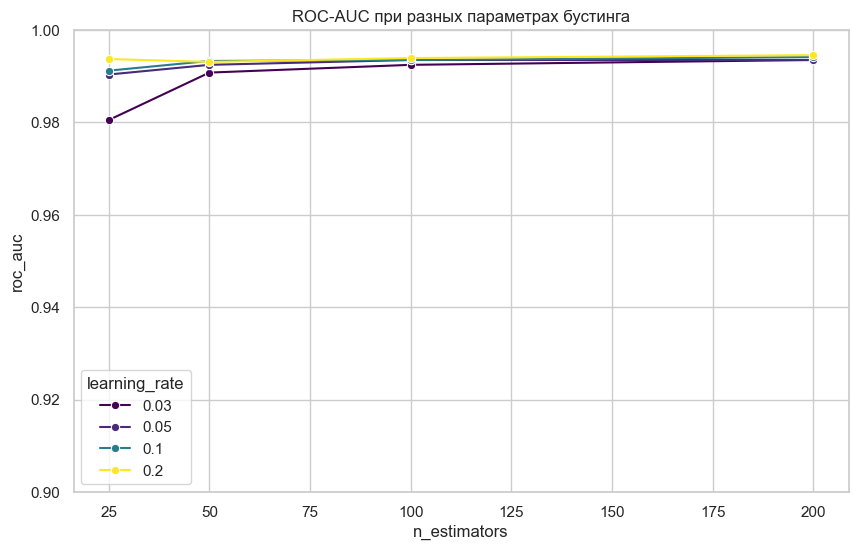

In [3]:
rows = []
for learning_rate in [0.03, 0.05, 0.1, 0.2]:
    for n_estimators in [25, 50, 100, 200]:
        model = GradientBoostingClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=2,
            random_state=42,
        )
        model.fit(train_features, train_target)
        probability = model.predict_proba(test_features)[:, 1]
        rows.append({
            "learning_rate": learning_rate,
            "n_estimators": n_estimators,
            "roc_auc": roc_auc_score(test_target, probability),
        })

experiments = pd.DataFrame(rows)
display(experiments.sort_values("roc_auc", ascending=False).head())

plt.figure(figsize=(10, 6))
sns.lineplot(data=experiments, x="n_estimators", y="roc_auc", hue="learning_rate", marker="o", palette="viridis")
plt.title("ROC-AUC при разных параметрах бустинга")
plt.ylim(0.9, 1.0)
plt.show()

## Лучшая конфигурация

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


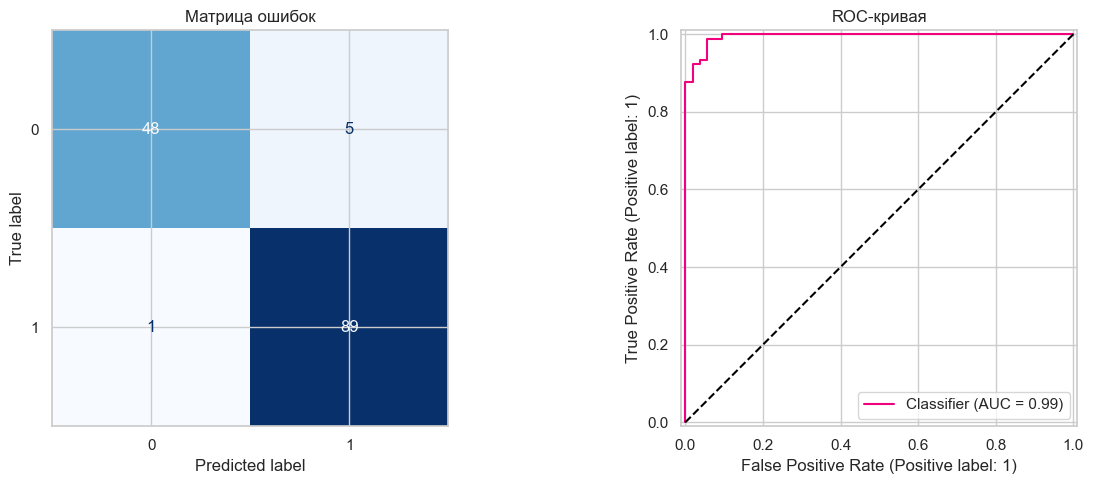

In [4]:
best = experiments.sort_values("roc_auc", ascending=False).iloc[0]
best_model = GradientBoostingClassifier(
    learning_rate=float(best["learning_rate"]),
    n_estimators=int(best["n_estimators"]),
    max_depth=2,
    random_state=42,
)
best_model.fit(train_features, train_target)
prediction = best_model.predict(test_features)
probability = best_model.predict_proba(test_features)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(test_target, prediction, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Матрица ошибок")
RocCurveDisplay.from_predictions(test_target, probability, ax=axes[1], color="#f0027f")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="black")
axes[1].set_title("ROC-кривая")
plt.tight_layout()
plt.show()

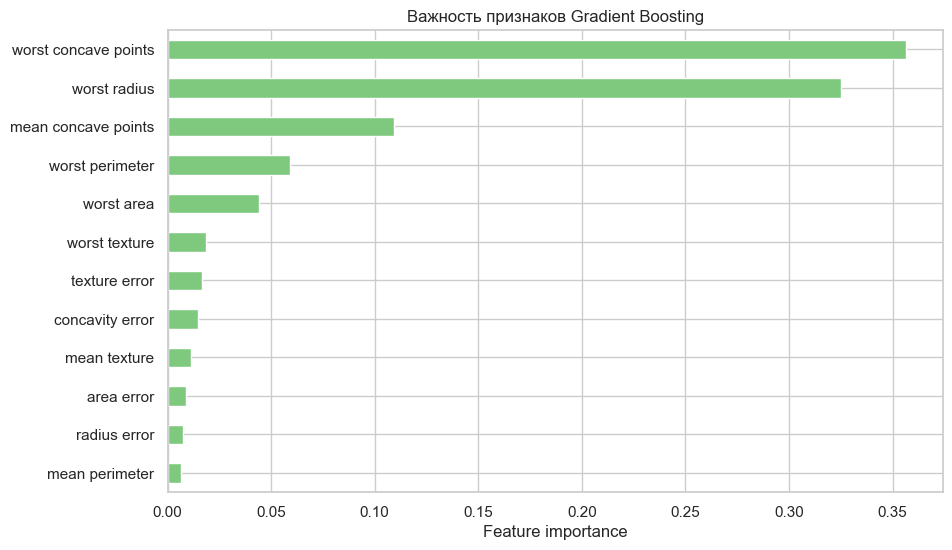

In [5]:
importance = pd.Series(best_model.feature_importances_, index=features.columns).nlargest(12).sort_values()
importance.plot.barh(figsize=(10, 6), color="#7fc97f")
plt.title("Важность признаков Gradient Boosting")
plt.xlabel("Feature importance")
plt.show()

## Вывод

Learning rate и число деревьев связаны: меньший шаг обычно требует больше итераций. Подбор выполняется на валидации, а test-выборка должна использоваться только для итоговой оценки.